# Cleaning Data

## Oasis Infobyte Data Analytics Internship

This notebook focuses on cleaning a messy dataset by checking missing values, duplicate records, inconsistent formatting, incorrect data types, and possible outliers.

The aim is to prepare the dataset for more reliable analysis.

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [78]:
raw_data_folder = Path("raw data")

csv_files = list(raw_data_folder.glob("*.csv"))

csv_files

[WindowsPath('raw data/AB_NYC_2019.csv')]

In [79]:
file_path = csv_files[0]
df = pd.read_csv(file_path)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 1. Data Inspection

In this section, I will inspect the dataset to understand its size, column names, data types, missing values, and duplicate records before cleaning.

In [80]:
df.shape

(48895, 16)

In [81]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [83]:
missing_values = df.isnull().sum()

missing_values

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [84]:
duplicate_rows = df.duplicated().sum()

duplicate_rows

np.int64(0)

## 2. Data Cleaning

In this section, I will clean the dataset by fixing missing values, removing duplicate records, converting date columns, and handling invalid or unusual values.

In [85]:
df_clean = df.copy()

In [86]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df_clean.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [87]:
df_clean["name"] = df_clean["name"].fillna("Unknown Listing")
df_clean["host_name"] = df_clean["host_name"].fillna("Unknown Host")
df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0)

In [88]:
df_clean["last_review"] = pd.to_datetime(df_clean["last_review"], errors="coerce")

In [89]:
df_clean = df_clean.drop_duplicates()

In [90]:
df_clean = df_clean[df_clean["price"] > 0]

In [91]:
missing_values_after = df_clean.isnull().sum()

missing_values_after

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10051
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [92]:
df_clean.shape

(48884, 16)

## 3. Outlier Detection

In this section, I will check for unusual values in important numerical columns such as price and minimum nights. Outliers are not always wrong, but they should be reviewed because they can affect analysis results.

In [93]:
df_clean["price"].describe()

count    48884.000000
mean       152.755053
std        240.170260
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [94]:
df_clean.sort_values(by="price", ascending=False).head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
9151,7003697,Furnished room in Astoria apartment,20582832,Kathrine,Queens,Astoria,40.76810,-73.91651,Private room,10000,100,2,2016-02-13,0.04,1,0
17692,13894339,Luxury 1 bedroom apt. -stunning Manhattan views,5143901,Erin,Brooklyn,Greenpoint,40.73260,-73.95739,Entire home/apt,10000,5,5,2017-07-27,0.16,1,0
29238,22436899,1-BR Lincoln Center,72390391,Jelena,Manhattan,Upper West Side,40.77213,-73.98665,Entire home/apt,10000,30,0,NaT,0.00,1,83
12342,9528920,"Quiet, Clean, Lit @ LES & Chinatown",3906464,Amy,Manhattan,Lower East Side,40.71355,-73.98507,Private room,9999,99,6,2016-01-01,0.14,1,83
40433,31340283,2br - The Heart of NYC: Manhattans Lower East ...,4382127,Matt,Manhattan,Lower East Side,40.71980,-73.98566,Entire home/apt,9999,30,0,NaT,0.00,1,365
6530,4737930,Spanish Harlem Apt,1235070,Olson,Manhattan,East Harlem,40.79264,-73.93898,Entire home/apt,9999,5,1,2015-01-02,0.02,1,0
30268,23377410,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,18128455,Rum,Manhattan,Tribeca,40.72197,-74.00633,Entire home/apt,8500,30,2,2018-09-18,0.18,1,251
4377,2953058,Film Location,1177497,Jessica,Brooklyn,Clinton Hill,40.69137,-73.96723,Entire home/apt,8000,1,1,2016-09-15,0.03,11,365
29662,22779726,East 72nd Townhouse by (Hidden by Airbnb),156158778,Sally,Manhattan,Upper East Side,40.76824,-73.95989,Entire home/apt,7703,1,0,NaT,0.00,12,146
45666,34895693,Gem of east Flatbush,262534951,Sandra,Brooklyn,East Flatbush,40.65724,-73.92450,Private room,7500,1,8,2019-07-07,6.15,2,179


C:\Users\Administrator\AppData\Local\Temp\ipykernel_21260\4183218433.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_clean["price"], vert=False)


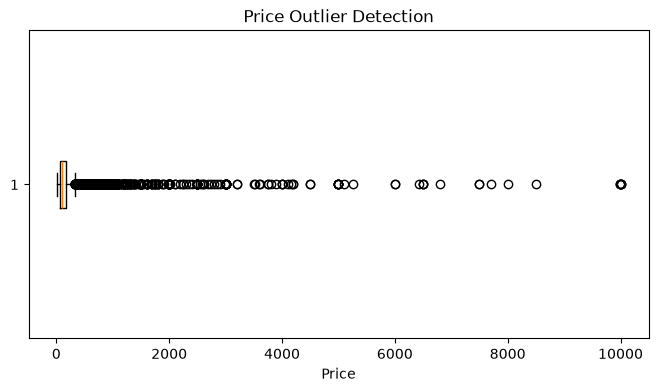

In [95]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_clean["price"], vert=False)
plt.title("Price Outlier Detection")
plt.xlabel("Price")
plt.show()

In [96]:
price_limit = df_clean["price"].quantile(0.99)

price_limit

np.float64(799.0)

In [97]:
df_clean = df_clean[df_clean["price"] <= price_limit]

df_clean.shape

(48410, 16)

In [98]:
cleaned_data_folder = Path("Cleaned data")
cleaned_data_folder.mkdir(exist_ok=True)

cleaned_file_path = cleaned_data_folder / "cleaned_airbnb_data.csv"

df_clean.to_csv(cleaned_file_path, index=False)

cleaned_file_path

WindowsPath('Cleaned data/cleaned_airbnb_data.csv')

## 4. Final Cleaning Summary

The dataset was cleaned by handling missing values, checking duplicate records, converting the last review column into a date format, removing invalid prices, reviewing outliers, and saving a cleaned version of the dataset.

The cleaned dataset is saved in the `Cleaned data` folder.

In [99]:
df_clean.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [100]:
price_limit = df_clean["price"].quantile(0.99)

price_limit

np.float64(550.0)

In [101]:
df_clean = df_clean[df_clean["price"] <= price_limit]

df_clean.shape

(47949, 16)

In [102]:
df_clean.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [103]:
cleaned_data_folder = Path("Cleaned data")
cleaned_data_folder.mkdir(exist_ok=True)

cleaned_file_path = cleaned_data_folder / "cleaned_airbnb_data.csv"

df_clean.to_csv(cleaned_file_path, index=False)

cleaned_file_path

WindowsPath('Cleaned data/cleaned_airbnb_data.csv')